# Hydro Generation in AIB Countries

This notebook quantifies hydro power generation across AIB (Association of Issuing Bodies) member countries using ENTSO-E actual generation data, and compares it to Guarantee of Origin (GO) issuance volumes. Only run-of-river and water reservoir generation are included, as these are fully eligible for GO issuance. Pumped storage is excluded since only the natural inflow portion qualifies for GOs.

In [34]:
aib_members = [
    'AL', 'AT', 'BE', 'BA', 'BG', 'HR', 'CY', 'CZ', 'DK', 'EE',
    'FI', 'FR', 'GE', 'DE', 'GR', 'HU', 'IS', 'IE', 'IT', 'XK', 
    'LV', 'LT', 'LU', 'ME', 'NL', 'MK', 'NO', 'PT', 'RO', 'RS', 
    'SK', 'SI', 'ES', 'SE', 'CH', 'UA'
]

aib_electricity_scheme_group = [
    'AT', 'BE', 'HR', 'CY', 'CZ', 'DK', 'EE', 'FI', 'FR', 'DE', 
    'GR', 'HU', 'IS', 'IE', 'IT', 'LV', 'LT', 'LU', 'NL', 'NO', 
    'PT', 'RS', 'SK', 'SI', 'ES', 'SE', 'CH'
]

country_to_grid = {'AT': 'APG', 'BE': 'ELIA', 'FR': 'RTE', 'GB': 'NGRID', 'NL': 'TENNET'}
grid_to_country = {v: k for k, v in country_to_grid.items()}

## Data Collection

We query the ENTSO-E hydro production curves from the database. Hydro generation is reported in three categories: run-of-river (RoR), water reservoir, and pumped storage. For GO comparison purposes, we use only RoR and reservoir generation as these are fully eligible for GO issuance. Pumped storage generation is excluded because only the natural inflow component qualifies — the pumped portion consumed grid electricity. Some countries (NO, SE, DK) report by bidding zone which must be summed to get a national total.

In [35]:
from kad_functions.sql_data import get_sql_query

hydro_query = """
SELECT CurveId, CurveName, CountryCode
FROM pub.dimMetadata
WHERE (CurveName LIKE '%entsoe-power-production%hydro%'
    OR CurveName LIKE '%EntsoE-ActualGeneration%hydro%'
    OR CurveName LIKE '%EntsoE_Actual_Generation%hydro%'
    OR CurveName LIKE '%EntsoE_ActualGeneration%hydro%')
    AND Curvename NOT LIKE '%raw'
ORDER BY CountryCode
"""

hydro_countries = get_sql_query(hydro_query)
hydro_countries = hydro_countries.sort_values(by='CountryCode').reset_index(drop=True)

# Fix country code assignments where CurveName contains grid operator names
hydro_countries.loc[hydro_countries['CurveName'].str.contains('ACTUAL-NO', case=False, na=False), 'CountryCode'] = 'NO'

hydro_countries = hydro_countries[hydro_countries['CountryCode'].isin(aib_electricity_scheme_group)]
hydro_countries = hydro_countries.sort_values(by='CountryCode').reset_index(drop=True)

display(hydro_countries)

,CurveId,CurveName,CountryCode
0,1000300318,ENTSOE-POWER-PRODUCTION-ACTUAL-HYDRO-PUMPED-ST...,BE
1,1500029390,ENTSOE-POWER-PRODUCTION-ACTUAL-BE-HYDRO-PUMPED...,BE
2,1500029391,ENTSOE-POWER-PRODUCTION-ACTUAL-BE-HYDRO-ROR-MW,BE
3,1500029392,ENTSOE-POWER-PRODUCTION-ACTUAL-BE-HYDRO-WATER-...,BE
4,910003000,ENTSOE_ActualGeneration_CZ_HYDRO-RESERVOIR__PROD,CZ
...,...,...,...
82,910003058,ENTSOE_ActualGeneration_SI_HYDRO-RUN-OF-RIVER_...,SI
83,910003013,ENTSOE_ActualGeneration_SK_HYDRO-PUMPED-STORAG...,SK
84,910003014,ENTSOE_ActualGeneration_SK_HYDRO-RUN-OF-RIVER_...,SK
85,910003012,ENTSOE_ActualGeneration_SK_HYDRO-PUMPED-STORAG...,SK


In [36]:
# Country filters - selected curve IDs to avoid double-counting
# Strategy: include RUN-OF-RIVER + WATER RESERVOIR only (fully GO-eligible)
# Exclude PUMPED STORAGE (only natural inflow portion qualifies for GOs)
# Only PROD (not CONS), sum regional curves for NO/SE/DK
filtered_curve_ids = [
    '1500029391', '1500029392',  # BE RoR, reservoir
    '910002999', '910003000',    # CZ RoR PROD, reservoir PROD
    '1500028329', '1500028330',  # DK1 RoR, reservoir
    '1500028351', '1500028352',  # DK2 RoR, reservoir
    '1500029052', '1500029053',  # EE RoR, reservoir
    '1000341691', '1500028306',  # FI RoR, reservoir
    '910003085',                 # GR reservoir PROD
    '910004523', '910004524',    # HR RoR PROD, reservoir PROD
    '910003026', '910003027',    # HU RoR PROD, reservoir PROD
    '1500029102', '1500029103',  # LT RoR, reservoir
    '1500029074', '1500029075',  # LV RoR, reservoir
    '1500029369', '1500029370',  # NL RoR, reservoir
    # NO bidding zones - RoR + reservoir
    '1500026488', '1500026489',  # NO1 RoR, reservoir
    '1500026530', '1500026531',  # NO2 RoR, reservoir
    '1500026572', '1500026573',  # NO3 RoR, reservoir
    '1500026614', '1500026615',  # NO4 RoR, reservoir
    '1500026656', '1500026657',  # NO5 RoR, reservoir
    '910003067', '910003068',    # RS RoR PROD, reservoir PROD
    # SE bidding zones - RoR + reservoir
    '1500026313', '1500026314',  # SE1 RoR, reservoir
    '1500026354', '1500026355',  # SE2 RoR, reservoir
    '1500026396', '1500026397',  # SE3 RoR, reservoir
    '1500026438', '1500026439',  # SE4 RoR, reservoir
    '910003058',                 # SI RoR PROD
    '910003014', '910003015',    # SK RoR PROD, reservoir PROD
]

# Filter hydro_countries to only selected curves
hydro_countries = hydro_countries[hydro_countries['CurveId'].astype(str).isin(filtered_curve_ids)].reset_index(drop=True)
print(f"Filtered to {len(hydro_countries)} curves across {hydro_countries['CountryCode'].nunique()} countries")
display(hydro_countries)

Filtered to 46 curves across 16 countries


,CurveId,CurveName,CountryCode
0,1500029391,ENTSOE-POWER-PRODUCTION-ACTUAL-BE-HYDRO-ROR-MW,BE
1,1500029392,ENTSOE-POWER-PRODUCTION-ACTUAL-BE-HYDRO-WATER-...,BE
2,910003000,ENTSOE_ActualGeneration_CZ_HYDRO-RESERVOIR__PROD,CZ
3,910002999,ENTSOE_ActualGeneration_CZ_HYDRO-RUN-OF-RIVER_...,CZ
4,1500028351,ENTSOE-POWER-PRODUCTION-ACTUAL-DK2-HYDRO-ROR-P...,DK
5,1500028352,ENTSOE-POWER-PRODUCTION-ACTUAL-DK2-HYDRO-WATER...,DK
6,1500028329,ENTSOE-POWER-PRODUCTION-ACTUAL-DK1-HYDRO-ROR-P...,DK
7,1500028330,ENTSOE-POWER-PRODUCTION-ACTUAL-DK1-HYDRO-WATER...,DK
8,1500029053,ENTSOE-POWER-PRODUCTION-ACTUAL-EE-HYDRO-WATER-...,EE
9,1500029052,ENTSOE-POWER-PRODUCTION-ACTUAL-EE-HYDRO-ROR-MW,EE


In [37]:
available_hydro_countries = sorted(set(hydro_countries['CountryCode']))

print("Countries with hydro generation data:", available_hydro_countries)
print("Number of countries with hydro generation data:", len(available_hydro_countries))
print("Countries without hydro generation data:", sorted(set(aib_electricity_scheme_group) - set(available_hydro_countries)))

Countries with hydro generation data: ['BE', 'CZ', 'DK', 'EE', 'FI', 'GR', 'HR', 'HU', 'LT', 'LV', 'NL', 'NO', 'RS', 'SE', 'SI', 'SK']
Number of countries with hydro generation data: 16
Countries without hydro generation data: ['AT', 'CH', 'CY', 'DE', 'ES', 'FR', 'IE', 'IS', 'IT', 'LU', 'PT']


In [38]:
import pandas as pd
import matplotlib.pyplot as plt

def resample_generation_data(df, granularity='h'):
    df = df.resample('15min').ffill()
    df = df.resample(granularity).mean()
    return df

def get_curve_data(curve_id, granularity='h'):
    country_query = f"""
        SELECT ValueDateUTC, ForecastDateUTC, Value
        FROM pub.Timeseries1_v02
        WHERE CurveId = {curve_id}
        AND ValueDateUTC >= '2020-01-01'
    """

    data = get_sql_query(country_query)
    data = data.sort_values('ForecastDateUTC').drop_duplicates(subset='ValueDateUTC', keep='last')
    data['ValueDateUTC'] = pd.to_datetime(data['ValueDateUTC'])
    data = data.set_index('ValueDateUTC').sort_index()
    data = data.drop(columns=['ForecastDateUTC'])

    resampled = resample_generation_data(data['Value'], granularity=granularity)
    return resampled

hydro_generation = {}

for country_code in available_hydro_countries:
    curve_ids = hydro_countries[hydro_countries['CountryCode'] == country_code]['CurveId'].values

    if len(curve_ids) > 0:
        country_data = {}
        for curve_id in curve_ids:
            print(f"Fetching hydro curve {curve_id} for {country_code}")
            country_data[curve_id] = get_curve_data(curve_id)
        hydro_generation[country_code] = pd.DataFrame(country_data).sum(axis=1)

# Build DataFrame with countries as columns, hourly datetime as index
df_hydro = pd.DataFrame(hydro_generation)
df_hydro = df_hydro.dropna(axis=1, how='all')

print(f"\nHydro generation data: {df_hydro.shape[1]} countries")
display(df_hydro)

Fetching hydro curve 1500029391 for BE
Fetching hydro curve 1500029392 for BE
Fetching hydro curve 910003000 for CZ
Fetching hydro curve 910002999 for CZ
Fetching hydro curve 1500028351 for DK
Fetching hydro curve 1500028352 for DK
Fetching hydro curve 1500028329 for DK
Fetching hydro curve 1500028330 for DK
Fetching hydro curve 1500029053 for EE
Fetching hydro curve 1500029052 for EE
Fetching hydro curve 1500028306 for FI
Fetching hydro curve 1000341691 for FI
Fetching hydro curve 910003085 for GR
Fetching hydro curve 910004523 for HR
Fetching hydro curve 910004524 for HR
Fetching hydro curve 910003027 for HU
Fetching hydro curve 910003026 for HU
Fetching hydro curve 1500029103 for LT
Fetching hydro curve 1500029102 for LT
Fetching hydro curve 1500029074 for LV
Fetching hydro curve 1500029075 for LV
Fetching hydro curve 1500029369 for NL
Fetching hydro curve 1500029370 for NL
Fetching hydro curve 1500026656 for NO
Fetching hydro curve 1500026573 for NO
Fetching hydro curve 1500026531 

,CZ,DK,EE,FI,GR,HR,HU,LT,LV,NL,NO,RS,SE,SI,SK
ValueDateUTC,,,,,,,,,,,,,,,
2020-01-01 00:00:00,137.0000,2.0,0.9,980.0,476.00,91.0,31.35750,24.74,0.0,NaN,14969.080000,1188.0,NaN,441.000000,260.000
2020-01-01 01:00:00,138.0000,2.0,0.9,929.0,357.00,132.0,31.44750,24.86,0.0,NaN,14398.640000,973.0,NaN,420.000000,270.000
2020-01-01 02:00:00,139.0000,2.0,0.9,889.0,238.00,131.0,31.49000,24.84,3.0,NaN,13377.910000,713.0,NaN,388.000000,271.000
2020-01-01 03:00:00,139.0000,2.0,1.0,912.0,174.00,132.0,31.56750,24.86,107.0,NaN,12468.920000,444.0,NaN,384.000000,268.000
2020-01-01 04:00:00,137.0000,2.0,1.0,875.0,170.00,132.0,31.63500,24.79,219.0,NaN,11034.420000,379.0,NaN,361.000000,254.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-27 04:00:00,99.4500,NaN,0.0,1310.85,686.00,275.6,16.60075,48.647365,369.0,0.0,13532.359933,949.0,4251.3505,696.631952,303.175
2026-05-27 05:00:00,99.2300,NaN,0.0,1335.5,357.50,253.6,16.27225,36.237406,178.0,0.0,14260.558394,1165.0,4333.513,553.643934,279.500
2026-05-27 06:00:00,88.9425,NaN,0.0,1313.975,111.00,148.7,15.61100,43.009689,174.0,0.0,12727.305570,358.0,4301.63375,344.273966,171.125


## Hydro Generation Overview

The following plot shows monthly average hydro generation (run-of-river + reservoir) across the available AIB member countries. Hydro generation exhibits seasonal patterns driven by precipitation and snowmelt, with Nordic countries (NO, SE) dominating European hydro production.

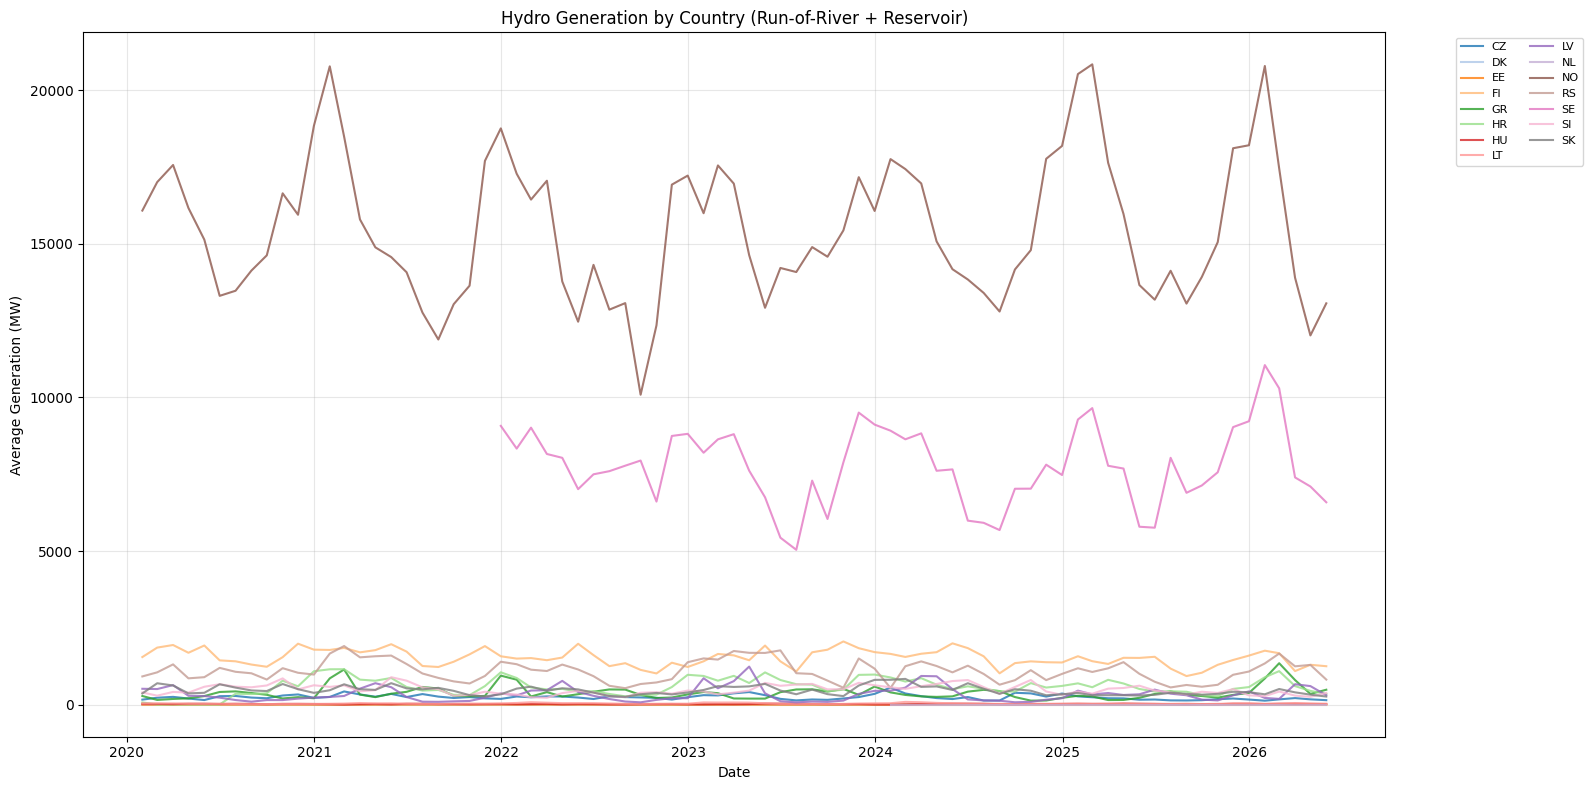

In [39]:
fig, ax = plt.subplots(1, 1, figsize=(16, 8))

# Assign consistent colors to all countries
all_countries = sorted(df_hydro.columns)
_colors = (plt.cm.tab20.colors[:20] + plt.cm.Set3.colors[:7])
country_colors = {country: _colors[i % len(_colors)] for i, country in enumerate(all_countries)}

# Monthly average hydro generation
monthly_hydro = df_hydro.resample('ME').mean()
for country in sorted(monthly_hydro.columns):
    ax.plot(monthly_hydro.index, monthly_hydro[country], label=country, alpha=0.8, color=country_colors[country])
ax.set_xlabel('Date')
ax.set_ylabel('Average Generation (MW)')
ax.set_title('Hydro Generation by Country (Run-of-River + Reservoir)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Comparison with GO Issuances

We compare ENTSO-E actual hydro generation (run-of-river + reservoir, converted to MWh) with GO issuance data from AIB statistics. The GO data is filtered for electricity certificates with hydro as the energy source. Monthly generation is matched to monthly GO issuance by country.

In [40]:
import pandas as pd

path_1 = "/Users/kad/Library/CloudStorage/OneDrive-InCommoditiesAS/Data/GOs/GO_All_Statistics_1.csv"
df_1 = pd.read_csv(path_1, sep=",")

path_2 = "/Users/kad/Library/CloudStorage/OneDrive-InCommoditiesAS/Data/GOs/GO_All_Statistics_2.csv"
df_2 = pd.read_csv(path_2, sep=",")

df = pd.concat([df_1, df_2], ignore_index=True)

display(df)

,year_month_date,year,month_name,domain_name,energy_carrier,energy_source_name,energy_source_level1,energy_source_level2,production_technology_name,production_date_cancel,production_date_expire,production_date_issue,transaction_date_cancel,transaction_date_expire,transaction_date_export,transaction_date_import,transaction_date_issue,transaction_date_transfer,transaction_date_withdraw
0,2025-03-01,2025,March,PT - Portugal,EECS-Electricity,F01010101,Renewable,Renewable - Biomass,T050202,0,0,0,0,0,0,1134,0,0,0
1,2026-03-01,2026,March,CZ - Czech Republic,EECS-Electricity,F01030400,Renewable,Renewable - Biomass,T050500,0,0,0,1918,0,0,1918,0,0,0
2,2025-05-01,2025,May,FR - France,EECS-Electricity,F01010301,Renewable,Renewable - Biomass,T050301,5529,0,0,0,0,0,0,0,0,0
3,2023-03-01,2023,March,CZ - Czech Republic,EECS-Electricity,F01050100,Renewable,Renewable - Wind,T020000,59613,447,44798,92322,2238,27707,41757,44047,47886,0
4,2024-03-01,2024,March,FR - France,EECS-Electricity,F01030400,Renewable,Renewable - Biomass,T050502,0,0,0,2000,0,0,2000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114135,2022-12-01,2022,December,IT - Italy,EECS-Electricity,F01010101,Renewable,Renewable - Biomass,T050000,147307,0,128702,0,0,7254,263060,154040,10722,0
114136,2019-05-01,2019,May,NO - Norway,EECS-Electricity,F01050200,Renewable,Renewable - Hydro & Marine,T030000,2309808,40178,8019101,356688,817501,3432797,415589,7062114,984905,0
114137,2020-04-01,2020,April,AT - Austria,EECS-Electricity,F01030300,Renewable,Renewable - Biomass,T050501,0,0,0,357,0,0,0,0,0,0
114138,2022-02-01,2022,February,AT - Austria,EECS-Electricity,F01010300,Renewable,Renewable - Biomass,T050202,0,0,0,0,0,0,0,0,14626,0


In [41]:
go_df = df.copy()

# Only consider energy carrier electricity for now
go_df = go_df[go_df['energy_carrier'].str.contains('Electricity')]

# Calendar columns
go_df["month"] = go_df["year_month_date"].str.split("-").str[1].astype(int)
go_df["year"] = go_df["year"].astype(int)

go_df = go_df.drop(columns=["year_month_date", "month_name"])

# Classification columns
go_df['country_code'] = go_df['domain_name'].str.split(' ').str[0].astype(str)
go_df['energy_source_category'] = go_df['energy_source_level1'].astype(str)
go_df['energy_source'] = go_df['energy_source_level2'].str.split(' ').str[-1].astype(str)

go_df = go_df.drop(columns=['domain_name', 'energy_carrier', 'energy_source_name', 'energy_source_level1', 'energy_source_level2', 'production_technology_name'])

# Columns reordering
go_df = go_df[['year', 'month', 'country_code', 'energy_source_category', 'energy_source'] + go_df.columns[1:11].tolist()]

# Remove incomplete last month data
go_df = go_df[(go_df['year'] >= 2020) & ~((go_df['year'] == 2026) & (go_df['month'] == 4))]

display(go_df)

,year,month,country_code,energy_source_category,energy_source,production_date_cancel,production_date_expire,production_date_issue,transaction_date_cancel,transaction_date_expire,transaction_date_export,transaction_date_import,transaction_date_issue,transaction_date_transfer,transaction_date_withdraw
0,2025,3,PT,Renewable,Biomass,0,0,0,0,0,0,1134,0,0,0
1,2026,3,CZ,Renewable,Biomass,0,0,0,1918,0,0,1918,0,0,0
2,2025,5,FR,Renewable,Biomass,5529,0,0,0,0,0,0,0,0,0
3,2023,3,CZ,Renewable,Wind,59613,447,44798,92322,2238,27707,41757,44047,47886,0
4,2024,3,FR,Renewable,Biomass,0,0,0,2000,0,0,2000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114133,2021,11,DK,Renewable,Marine,46596,0,190,0,4673,1024,11840,233,0,0
114135,2022,12,IT,Renewable,Biomass,147307,0,128702,0,0,7254,263060,154040,10722,0
114137,2020,4,AT,Renewable,Biomass,0,0,0,357,0,0,0,0,0,0
114138,2022,2,AT,Renewable,Biomass,0,0,0,0,0,0,0,0,14626,0


In [42]:
# Filter GO data for hydro only
hydro_go = go_df[go_df['energy_source'] == 'Marine'].copy()

# Monthly GO issuance (MWh) by country
go_issued = hydro_go.groupby(['year', 'month', 'country_code'])['production_date_issue'].sum().reset_index()
go_issued.columns = ['year', 'month', 'country_code', 'go_issued_mwh']
go_issued['date'] = pd.to_datetime(go_issued[['year', 'month']].assign(day=1))

# Monthly ENTSO-E generation (MW hourly -> MWh by summing hourly values)
monthly_gen_mwh = df_hydro.resample('ME').sum()  # sum of hourly MW = MWh

# Reshape to long format for comparison
gen_long = monthly_gen_mwh.reset_index().melt(id_vars='ValueDateUTC', var_name='country_code', value_name='entsoe_mwh')
gen_long['year'] = gen_long['ValueDateUTC'].dt.year
gen_long['month'] = gen_long['ValueDateUTC'].dt.month

# Merge GO issuance with ENTSO-E generation
comparison = gen_long.merge(go_issued, on=['year', 'month', 'country_code'], how='outer')
comparison['date'] = pd.to_datetime(comparison[['year', 'month']].assign(day=1))
comparison = comparison.sort_values(['country_code', 'date'])

# GO issuance rate (% of generation that got GOs issued)
entsoe_safe = comparison['entsoe_mwh'].where(comparison['entsoe_mwh'] != 0)
comparison['go_rate'] = comparison['go_issued_mwh'] / entsoe_safe * 100

display(comparison[['date', 'country_code', 'entsoe_mwh', 'go_issued_mwh', 'go_rate']].dropna(subset=['entsoe_mwh', 'go_issued_mwh']))

,date,country_code,entsoe_mwh,go_issued_mwh,go_rate
5,2020-01-01,CZ,122946.0,91156.0,74.14312
33,2020-02-01,CZ,158265.0,126441.0,79.891953
61,2020-03-01,CZ,189782.0,144016.0,75.884963
89,2020-04-01,CZ,144309.0,105169.0,72.877644
117,2020-05-01,CZ,112722.0,83459.0,74.039673
...,...,...,...,...,...
1994,2025-11-01,SK,302523.2,283123.0,93.587203
2022,2025-12-01,SK,302984.8,277367.0,91.544856
2051,2026-01-01,SK,252052.5,233194.0,92.518027
2080,2026-02-01,SK,343382.4,322197.0,93.830377


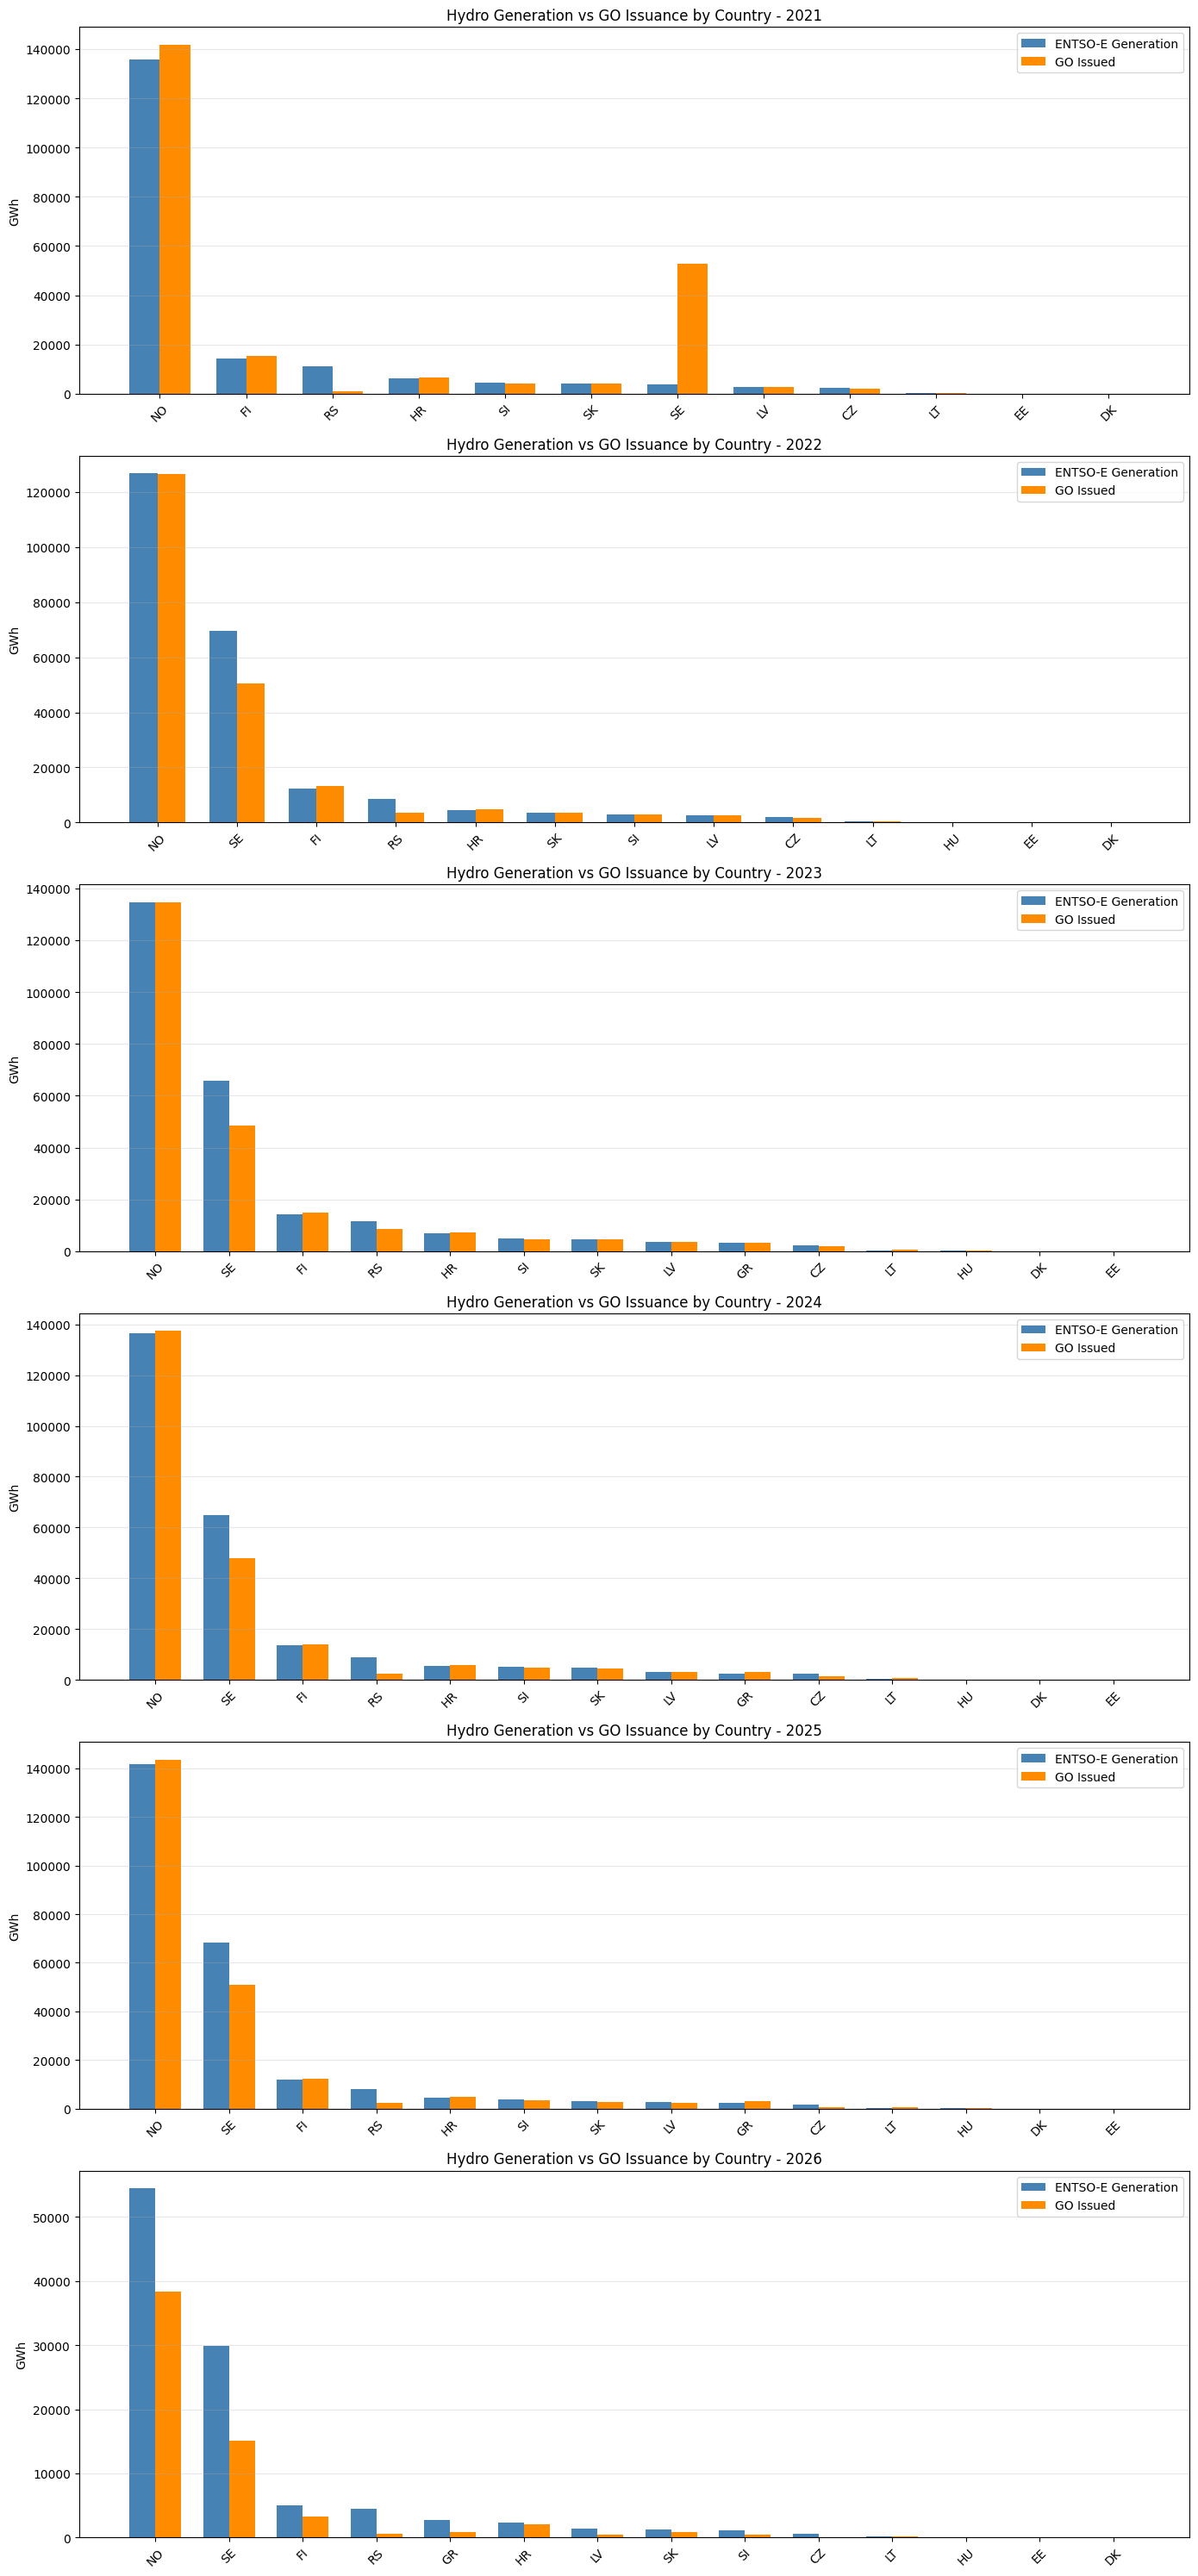

In [43]:
# Plot comparison: annual totals by country
annual = comparison.groupby(['country_code', comparison['date'].dt.year]).agg(
    entsoe_gwh=('entsoe_mwh', lambda x: x.sum() / 1e3),
    go_issued_gwh=('go_issued_mwh', lambda x: x.sum() / 1e3)
).reset_index()
annual.columns = ['country_code', 'year', 'entsoe_gwh', 'go_issued_gwh']

# Filter to countries present in both datasets and year 2021+
annual = annual[(annual['entsoe_gwh'] > 0) & (annual['go_issued_gwh'] > 0) & (annual['year'] >= 2021)]

# Plot per year
years = sorted(annual['year'].unique())
fig, axes = plt.subplots(len(years), 1, figsize=(14, 5 * len(years)))

for i, year in enumerate(years):
    ax = axes[i] if len(years) > 1 else axes
    year_data = annual[annual['year'] == year].sort_values('entsoe_gwh', ascending=False)
    
    x = range(len(year_data))
    width = 0.35
    ax.bar([p - width/2 for p in x], year_data['entsoe_gwh'], width, label='ENTSO-E Generation', color='steelblue')
    ax.bar([p + width/2 for p in x], year_data['go_issued_gwh'], width, label='GO Issued', color='darkorange')
    ax.set_xticks(list(x))
    ax.set_xticklabels(year_data['country_code'], rotation=45)
    ax.set_ylabel('GWh')
    ax.set_title(f'Hydro Generation vs GO Issuance by Country - {year}')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## GO Issuance Factors & 2026 Estimation

Calculate the average ratio of GO issuance to ENTSO-E generation per country (2021–2025), then apply these factors to 2026 generation to estimate expected GO volumes not yet issued.

In [46]:
# Calculate GO factor per country based on 2021-2025 annual totals
# Exclude SE 2021 due to presumed ENTSO-E reporting error (anomalously low generation)
historical = annual[(annual['year'] >= 2021) & (annual['year'] <= 2025)].copy()
historical = historical[~((historical['country_code'] == 'SE') & (historical['year'] == 2021))]
historical['go_factor'] = historical['go_issued_gwh'] / historical['entsoe_gwh']

# Average factor per country across all available years
go_factors = historical.groupby('country_code').agg(
    avg_factor=('go_factor', 'mean'),
    min_factor=('go_factor', 'min'),
    max_factor=('go_factor', 'max'),
    years_count=('year', 'count'),
    avg_gen_gwh=('entsoe_gwh', 'mean')
).sort_values('avg_gen_gwh', ascending=False).round(3)

print("GO Issuance Factor by Country (2021-2025)")
print("Factor = GO Issued / ENTSO-E Generation")
print("=" * 65)
display(go_factors)

# 2026 data: generation and already-issued GOs
gen_2026 = annual[annual['year'] == 2026][['country_code', 'entsoe_gwh', 'go_issued_gwh']].copy()
gen_2026 = gen_2026.merge(go_factors[['avg_factor']].reset_index(), on='country_code', how='left')

# Estimate expected total 2026 GOs and the not-yet-issued portion
gen_2026['expected_go_gwh'] = gen_2026['entsoe_gwh'] * gen_2026['avg_factor']
gen_2026['not_yet_issued_gwh'] = gen_2026['expected_go_gwh'] - gen_2026['go_issued_gwh']
gen_2026['pct_issued'] = (gen_2026['go_issued_gwh'] / gen_2026['expected_go_gwh'] * 100).round(1)
gen_2026 = gen_2026.sort_values('expected_go_gwh', ascending=False).round(1)

print("\n\n2026 Estimated Hydro GO Issuance vs Already Issued (GWh)")
print("Based on generation to date and historical GO factors")
print("=" * 75)
display(gen_2026[['country_code', 'entsoe_gwh', 'avg_factor', 'expected_go_gwh', 'go_issued_gwh', 'not_yet_issued_gwh', 'pct_issued']])

total_expected = gen_2026['expected_go_gwh'].sum()
total_issued = gen_2026['go_issued_gwh'].sum()
print(f"\nTotal across all countries:")
print(f"  Expected 2026 GOs (based on gen to date): {total_expected:,.0f} GWh")
print(f"  Already issued:                           {total_issued:,.0f} GWh")
print(f"  Not yet issued (estimated):               {total_expected - total_issued:,.0f} GWh")
print(f"  Issuance progress:                        {total_issued/total_expected*100:.1f}%")

GO Issuance Factor by Country (2021-2025)
Factor = GO Issued / ENTSO-E Generation


,avg_factor,min_factor,max_factor,years_count,avg_gen_gwh
country_code,,,,,
NO,1.013,0.999,1.044,5,135061.086
SE,0.735,0.723,0.743,4,67212.550
FI,1.050,1.029,1.070,5,13341.691
RS,0.364,0.074,0.749,5,9642.924
HR,1.063,1.051,1.087,5,5533.942
SI,0.943,0.934,0.958,5,4284.582
SK,0.978,0.960,0.986,5,4039.990
LV,0.962,0.799,1.010,5,3026.068
GR,1.150,1.009,1.234,3,2844.000




2026 Estimated Hydro GO Issuance vs Already Issued (GWh)
Based on generation to date and historical GO factors


,country_code,entsoe_gwh,avg_factor,expected_go_gwh,go_issued_gwh,not_yet_issued_gwh,pct_issued
9,NO,54452.0,1.0,55159.9,38362.4,16797.5,69.5
11,SE,29921.0,0.7,21991.9,15079.0,6912.9,68.6
3,FI,4975.0,1.0,5223.7,3337.6,1886.2,63.9
4,GR,2701.7,1.2,3107.0,789.1,2317.8,25.4
5,HR,2397.3,1.1,2548.3,2019.0,529.3,79.2
10,RS,4497.2,0.4,1637.0,626.1,1010.9,38.2
8,LV,1417.2,1.0,1363.4,419.8,943.6,30.8
13,SK,1298.3,1.0,1269.7,829.6,440.2,65.3
12,SI,1141.3,0.9,1076.2,458.6,617.6,42.6
0,CZ,592.6,0.7,390.5,54.8,335.7,14.0



Total across all countries:
  Expected 2026 GOs (based on gen to date): 94,092 GWh
  Already issued:                           62,251 GWh
  Not yet issued (estimated):               31,840 GWh
  Issuance progress:                        66.2%


## Conclusion

The comparison between ENTSO-E hydro generation (run-of-river + reservoir) and GO issuance across AIB member countries reveals several key patterns:

**Norway (NO):** By far the largest hydro producer (~130–140 TWh/year), with GO issuance very closely matching generation. In 2021, GO issuance even slightly exceeded measured generation, likely due to timing differences in issuance vs production reporting. From 2022 onwards, the match is nearly 1:1, reflecting a mature, fully-certified hydro GO market and Norway's role as Europe's largest GO exporter.

**Sweden (SE):** The second-largest producer (~65–70 TWh/year), but GO issuance consistently falls short at ~48–50 TWh/year (roughly 70–75% GO rate). This gap suggests a portion of Swedish hydro generation does not receive GOs — possibly older plants that predate the certificate system or capacity that has opted out. In 2021, SE data shows anomalously low ENTSO-E generation against high GO issuance, indicating incomplete ENTSO-E reporting for that year.

**Finland (FI):** The third-largest producer in our dataset (~12–14 TWh/year), showing a close match between generation and GO issuance across all years.

**Serbia (RS) and Croatia (HR):** Medium-sized hydro markets (~5–10 TWh/year). RS shows GO issuance somewhat below generation, while HR demonstrates a closer alignment.

**Smaller markets (SI, SK, LV, GR, CZ, LT, HU, EE, DK):** These countries have small hydro volumes (< 5 TWh/year). Most show reasonable alignment between generation and GO issuance, though volumes are too small to draw strong conclusions.

**Data coverage limitations:** Major hydro-producing countries — AT, CH, FR, ES, IT, PT — are absent from this ENTSO-E dataset. Their hydro curves either use different naming conventions or are stored under alternative data sources. This significantly limits the analysis for Southern/Alpine Europe where hydro is a dominant renewable source.

**Pumped storage exclusion:** By excluding pumped storage generation, we focus on the portion of hydro output that is fully GO-eligible. Countries with significant pumped storage (e.g., NO, SE) would show higher total hydro production if included, but the GO comparison would be less meaningful since only natural inflow qualifies for certification.